In [3]:
# Cell 1: Imports and Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

In [5]:
# Cell 2: Policy Network Definition
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_policy = nn.Linear(hidden_dim, action_dim)
        self.fc_value = nn.Linear(hidden_dim, 1)
        
    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        
        # Policy head (action probabilities)
        policy_logits = self.fc_policy(x)
        policy_probs = F.softmax(policy_logits, dim=-1)
        
        # Value head (state value)
        value = self.fc_value(x)
        
        return policy_probs, value, policy_logits


In [6]:
# Cell 3: GRPO Agent Class
class GRPOAgent:
    def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99, eps_clip=0.2, 
                 k_epochs=4, group_size=4, beta=0.01):
        self.gamma = gamma
        self.eps_clip = eps_clip
        self.k_epochs = k_epochs
        self.group_size = group_size
        self.beta = beta  # KL divergence coefficient
        
        # Initialize networks
        self.policy = PolicyNetwork(state_dim, action_dim).to(device)
        self.policy_old = PolicyNetwork(state_dim, action_dim).to(device)
        self.policy_old.load_state_dict(self.policy.state_dict())
        
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        
        # Storage for trajectories
        self.buffer = {
            'states': [],
            'actions': [],
            'rewards': [],
            'log_probs': [],
            'values': [],
            'dones': []
        }
        
    def select_action(self, state, training=True):
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        with torch.no_grad():
            policy_probs, value, _ = self.policy_old(state)
            
        # Sample action from policy
        dist = torch.distributions.Categorical(policy_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        
        if training:
            self.buffer['states'].append(state.cpu().numpy())
            self.buffer['actions'].append(action.item())
            self.buffer['log_probs'].append(log_prob.item())
            self.buffer['values'].append(value.item())
        
        return action.item()
    
    def store_transition(self, reward, done):
        self.buffer['rewards'].append(reward)
        self.buffer['dones'].append(done)
    
    def compute_advantages(self, rewards, values, dones):
        advantages = []
        returns = []
        
        # Compute returns and advantages using GAE
        gae = 0
        for i in reversed(range(len(rewards))):
            if i == len(rewards) - 1:
                next_value = 0
            else:
                next_value = values[i + 1]
            
            delta = rewards[i] + self.gamma * next_value * (1 - dones[i]) - values[i]
            gae = delta + self.gamma * 0.95 * (1 - dones[i]) * gae  # GAE-lambda with lambda=0.95
            
            advantages.insert(0, gae)
            returns.insert(0, gae + values[i])
        
        return torch.tensor(advantages, dtype=torch.float32).to(device), \
               torch.tensor(returns, dtype=torch.float32).to(device)
    
    def update(self):
        if len(self.buffer['states']) == 0:
            return
        
        # Convert buffer to tensors
        states = torch.FloatTensor(np.array(self.buffer['states']).squeeze()).to(device)
        actions = torch.LongTensor(self.buffer['actions']).to(device)
        old_log_probs = torch.FloatTensor(self.buffer['log_probs']).to(device)
        rewards = self.buffer['rewards']
        values = self.buffer['values']
        dones = self.buffer['dones']
        
        # Compute advantages and returns
        advantages, returns = self.compute_advantages(rewards, values, dones)
        
        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        # Group-based updates
        total_loss = 0
        num_groups = max(1, len(states) // self.group_size)
        
        for epoch in range(self.k_epochs):
            # Shuffle data
            indices = torch.randperm(len(states))
            
            for i in range(0, len(states), self.group_size):
                # Get group indices
                group_indices = indices[i:i + self.group_size]
                
                if len(group_indices) == 0:
                    continue
                
                # Get group data
                group_states = states[group_indices]
                group_actions = actions[group_indices]
                group_old_log_probs = old_log_probs[group_indices]
                group_advantages = advantages[group_indices]
                group_returns = returns[group_indices]
                
                # Forward pass
                policy_probs, state_values, policy_logits = self.policy(group_states)
                
                # Compute new log probabilities
                dist = torch.distributions.Categorical(policy_probs)
                new_log_probs = dist.log_prob(group_actions)
                
                # Compute ratio for PPO clipping
                ratio = torch.exp(new_log_probs - group_old_log_probs)
                
                # PPO policy loss
                surr1 = ratio * group_advantages
                surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * group_advantages
                policy_loss = -torch.min(surr1, surr2).mean()
                
                # Value loss
                value_loss = F.mse_loss(state_values.squeeze(), group_returns)
                
                # KL divergence regularization (GRPO component)
                with torch.no_grad():
                    old_policy_probs, _, _ = self.policy_old(group_states)
                
                kl_div = F.kl_div(F.log_softmax(policy_logits, dim=-1), 
                                old_policy_probs, reduction='batchmean')
                
                # Total loss
                loss = policy_loss + 0.5 * value_loss + self.beta * kl_div
                
                # Backward pass
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 0.5)
                self.optimizer.step()
                
                total_loss += loss.item()
        
        # Update old policy
        self.policy_old.load_state_dict(self.policy.state_dict())
        
        # Clear buffer
        self.clear_buffer()
        
        return total_loss / (num_groups * self.k_epochs) if num_groups > 0 else 0
    
    def clear_buffer(self):
        for key in self.buffer:
            self.buffer[key] = []


In [7]:

# Cell 4: Training Environment Setup
def create_env():
    env = gym.make('CartPole-v1')
    return env

def test_agent(agent, env, num_episodes=5):
    """Test the agent's performance"""
    total_rewards = []
    
    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]  # Handle new gym API
        
        episode_reward = 0
        done = False
        
        while not done:
            action = agent.select_action(state, training=False)
            next_state, reward, done, truncated, _ = env.step(action)
            
            if isinstance(next_state, tuple):
                next_state = next_state[0]
            
            done = done or truncated
            episode_reward += reward
            state = next_state
        
        total_rewards.append(episode_reward)
    
    return np.mean(total_rewards), np.std(total_rewards)


In [9]:

# Cell 5: Main Training Loop
def train_grpo_cartpole(num_episodes=1000, update_frequency=20):
    # Environment setup
    env = create_env()
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    print(f"State dimension: {state_dim}")
    print(f"Action dimension: {action_dim}")
    
    # Initialize agent
    agent = GRPOAgent(state_dim, action_dim)
    
    # Training metrics
    episode_rewards = []
    losses = []
    test_scores = []
    
    print("Starting GRPO training...")
    
    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]  # Handle new gym API
        
        episode_reward = 0
        done = False
        
        # Collect trajectory
        while not done:
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            
            if isinstance(next_state, tuple):
                next_state = next_state[0]
            
            done = done or truncated
            
            agent.store_transition(reward, done)
            episode_reward += reward
            state = next_state
        
        episode_rewards.append(episode_reward)
        
        # Update policy
        if (episode + 1) % update_frequency == 0:
            loss = agent.update()
            if loss is not None:
                losses.append(loss)
            
            # Test agent
            test_mean, test_std = test_agent(agent, env)
            test_scores.append(test_mean)
            
            print(f"Episode {episode + 1}/{num_episodes}")
            print(f"  Avg Reward (last {update_frequency}): {np.mean(episode_rewards[-update_frequency:]):.2f}")
            print(f"  Test Score: {test_mean:.2f} ± {test_std:.2f}")
            print(f"  Loss: {loss:.4f}" if loss is not None else "  Loss: N/A")
            print("-" * 50)
    
    env.close()
    
    return {
        'episode_rewards': episode_rewards,
        'losses': losses,
        'test_scores': test_scores,
        'agent': agent
    }

In [10]:

# Cell 6: Visualization Functions
def plot_results(results):
    """Plot training results"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Episode rewards
    axes[0, 0].plot(results['episode_rewards'], alpha=0.7)
    axes[0, 0].plot(np.convolve(results['episode_rewards'], np.ones(50)/50, mode='valid'), 
                   color='red', linewidth=2, label='50-episode average')
    axes[0, 0].set_title('Episode Rewards')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Losses
    if results['losses']:
        axes[0, 1].plot(results['losses'])
        axes[0, 1].set_title('Training Loss')
        axes[0, 1].set_xlabel('Update Step')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].grid(True)
    
    # Test scores
    if results['test_scores']:
        update_episodes = np.arange(20, len(results['episode_rewards']) + 1, 20)[:len(results['test_scores'])]
        axes[1, 0].plot(update_episodes, results['test_scores'], 'o-')
        axes[1, 0].set_title('Test Performance')
        axes[1, 0].set_xlabel('Episode')
        axes[1, 0].set_ylabel('Average Test Reward')
        axes[1, 0].grid(True)
    
    # Reward distribution (last 100 episodes)
    recent_rewards = results['episode_rewards'][-100:]
    axes[1, 1].hist(recent_rewards, bins=20, alpha=0.7)
    axes[1, 1].set_title('Reward Distribution (Last 100 Episodes)')
    axes[1, 1].set_xlabel('Reward')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()


State dimension: 4
Action dimension: 2
Starting GRPO training...


/var/folders/fz/_4_3bkv156zfzhgs_qdg_3rw0000gp/T/ipykernel_20176/1113100898.py:128: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  value_loss = F.mse_loss(state_values.squeeze(), group_returns)


Episode 20/500
  Avg Reward (last 20): 18.45
  Test Score: 16.00 ± 2.10
  Loss: 15.7440
--------------------------------------------------
Episode 40/500
  Avg Reward (last 20): 25.25
  Test Score: 24.80 ± 9.70
  Loss: 11.2388
--------------------------------------------------
Episode 60/500
  Avg Reward (last 20): 22.80
  Test Score: 32.80 ± 11.77
  Loss: 13.7961
--------------------------------------------------
Episode 80/500
  Avg Reward (last 20): 34.95
  Test Score: 62.20 ± 19.53
  Loss: 24.5752
--------------------------------------------------
Episode 100/500
  Avg Reward (last 20): 48.60
  Test Score: 52.60 ± 32.99
  Loss: 28.3036
--------------------------------------------------
Episode 120/500
  Avg Reward (last 20): 83.10
  Test Score: 72.00 ± 39.64
  Loss: 27.1085
--------------------------------------------------
Episode 140/500
  Avg Reward (last 20): 87.80
  Test Score: 70.60 ± 39.31
  Loss: 29.3136
--------------------------------------------------
Episode 160/500
  A

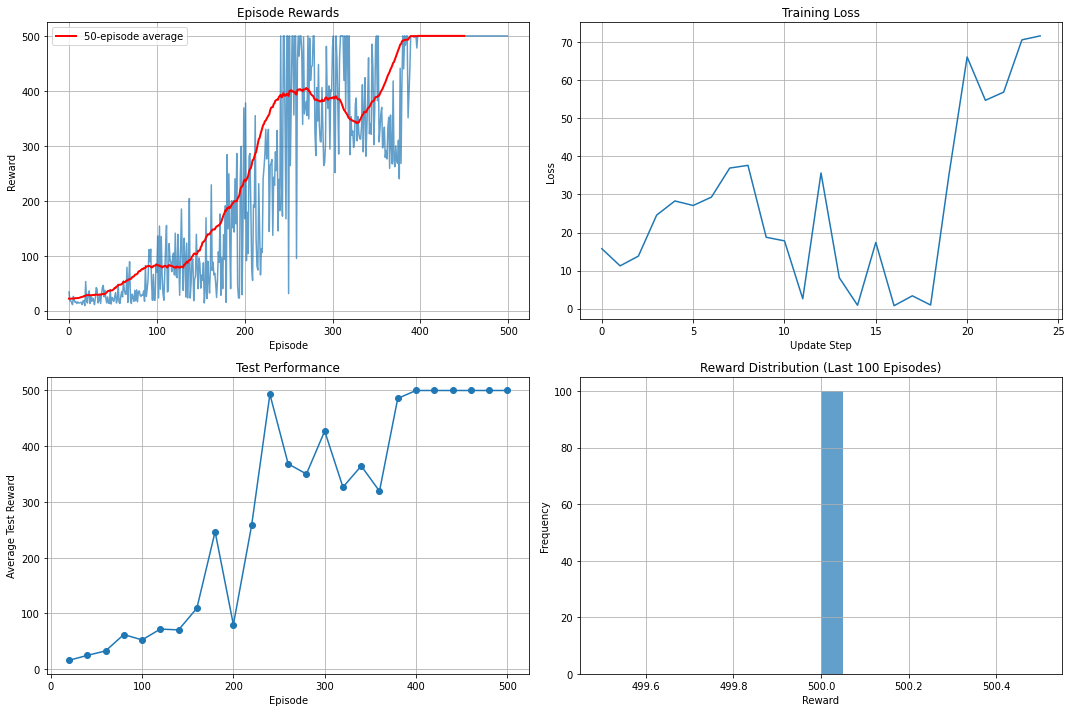


Final Test Results:
Average Score: 500.00 ± 0.00

Training completed!


In [11]:

# Cell 7: Run Training
if __name__ == "__main__":
    # Train the agent
    results = train_grpo_cartpole(num_episodes=500, update_frequency=20)
    
    # Plot results
    plot_results(results)
    
    # Final test
    env = create_env()
    final_score, final_std = test_agent(results['agent'], env, num_episodes=20)
    print(f"\nFinal Test Results:")
    print(f"Average Score: {final_score:.2f} ± {final_std:.2f}")
    env.close()
    
    print("\nTraining completed!")


In [12]:
# Cell 8: Demo Function (Optional)
def demo_trained_agent(agent, render=False):
    """Demonstrate the trained agent"""
    if render:
        env = gym.make('CartPole-v1', render_mode='human')
    else:
        env = gym.make('CartPole-v1')
    
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]
    
    total_reward = 0
    done = False
    step = 0
    
    print("Running demonstration...")
    
    while not done and step < 500:
        action = agent.select_action(state, training=False)
        next_state, reward, done, truncated, _ = env.step(action)
        
        if isinstance(next_state, tuple):
            next_state = next_state[0]
        
        done = done or truncated
        total_reward += reward
        state = next_state
        step += 1
        
        if render:
            env.render()
    
    print(f"Demo completed! Total reward: {total_reward}, Steps: {step}")
    env.close()
    
    return total_reward

# Uncomment to run demo after training:
demo_trained_agent(results['agent'], render=False)

Running demonstration...
Demo completed! Total reward: 500.0, Steps: 500


500.0